In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!ls ../

LICENSE  notebook   SSNMX_catalogo_19000101_20210908_utc.zip
main.py  README.md  venv


In [3]:
fname = "../SSNMX_catalogo_19000101_20210908_utc.zip"
df = pd.read_csv(fname, skiprows=4, skipfooter=7, engine='python')

In [4]:
df.head(20)

,Fecha UTC,Hora UTC,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha local,Hora local,Estatus
0,1900-01-20,06:33:30,7.4,20.00,-105.00,33.0,"71 km al NOROESTE de AUTLAN DE NAVARRO, JAL",1900-01-20,00:33:30,revisado
1,1900-05-16,20:12:00,6.9,20.00,-105.00,33.0,"71 km al NOROESTE de AUTLAN DE NAVARRO, JAL",1900-05-16,14:12:00,revisado
2,1901-03-05,10:45:00,6.9,25.00,-110.00,33.0,"100 km al NORESTE de LA PAZ, BCS",1901-03-05,04:45:00,revisado
3,1901-12-09,02:17:00,7.0,26.00,-110.00,33.0,"83 km al OESTE de AHOME, SIN",1901-12-08,20:17:00,revisado
4,1902-01-16,23:19:00,7.0,17.62,-99.72,33.0,"21 km al OESTE de ZUMPANGO DEL RIO, GRO",1902-01-16,17:19:00,revisado
5,1902-04-19,02:23:00,7.5,14.90,-91.50,25.0,"72 km al ESTE de CACAHOATAN, CHIS",1902-04-18,20:23:00,revisado
6,1902-09-23,20:18:00,7.7,16.50,-92.50,25.0,"5 km al SUROESTE de TEOPISCA, CHIS",1902-09-23,14:18:00,revisado
7,1902-12-12,23:10:00,7.1,29.00,-114.00,33.0,"115 km al NORTE de GUERRERO NEGRO, BCS",1902-12-12,17:10:00,revisado
8,1903-01-14,01:47:36,7.6,15.00,-93.00,33.0,"50 km al SUR de MAPASTEPEC, CHIS",1903-01-13,19:47:36,revisado
9,1905-10-24,17:40:00,6.6,20.00,-110.00,33.0,"320 km al SUR de CABO SAN LUCAS, BCS",1905-10-24,11:40:00,revisado


In [5]:
df = df[df['Magnitud']!='no calculable']

In [6]:
df['Magnitud'] = pd.to_numeric(df['Magnitud'])

In [7]:
#df = df[df['Magnitud'] > 2]

## Exploracion Basica

## Cuantos sismos ocurren al anio?

In [8]:
df['year'] = pd.to_numeric(df['Fecha UTC'].apply(lambda x : x.split('-')[0]))

In [9]:
df2 = df.groupby(by='year')['Magnitud'].count()

Text(0.5, 1.0, 'Quakes per year')

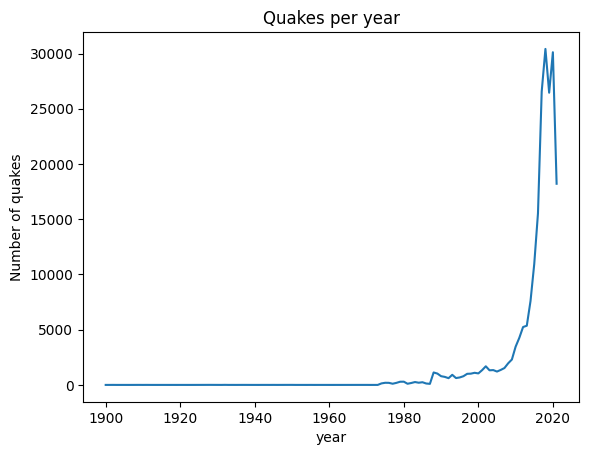

In [10]:
ax = sns.lineplot(df2)
ax.set_ylabel('Number of quakes')
ax.set_title('Quakes per year')

Tal vez la cantidad de dispositivos o su sensibilidad permite captar mayor cantidad de sismos en los ultimos 10 años?

## Que tan fuertes han sido esos sismos?

In [11]:
df['mag_int'] = df['Magnitud'].round().astype(int)

In [12]:
counts = df.groupby(['year','mag_int']).size().reset_index(name='count')

In [13]:
heatmap_data = counts.pivot(index='mag_int', columns='year', values='count')

In [14]:
heatmap_data = heatmap_data.fillna(0)

In [15]:
heatmap_data = heatmap_data.sort_index(ascending=False)

Text(0.5, 23.52222222222222, 'Año')

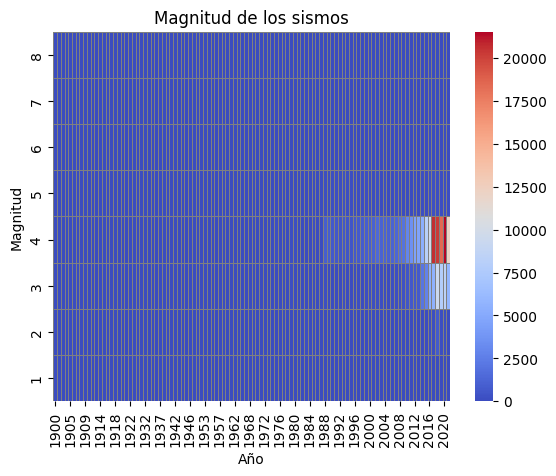

In [16]:
ax = sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5, linecolor='gray', fmt='.0f')
ax.set_title('Magnitud de los sismos')
ax.set_ylabel('Magnitud')
ax.set_xlabel('Año')

Parece que la mayor cantidad de sismos que se registran estan en el rango de 3-4.

## Hay meses que tienen mas actividad?

In [17]:
df['month'] = pd.to_numeric(df['Fecha UTC'].apply(lambda x : x.split('-')[1]))

In [18]:
counts = df.groupby(['year','month']).size().reset_index(name='count')

In [19]:
heatmap_data = counts.pivot(index='month', columns='year', values='count')

In [20]:
heatmap_data = heatmap_data.fillna(0)

In [21]:
heatmap_data = heatmap_data.sort_index(ascending=False)

Text(0.5, 23.52222222222222, 'Año')

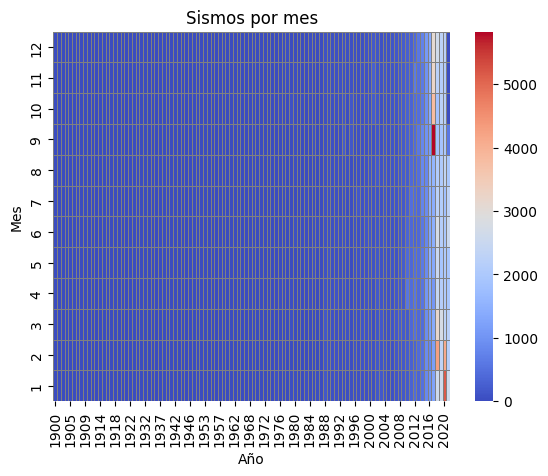

In [22]:
ax = sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5, linecolor='gray', fmt='.0f')
ax.set_title('Sismos por mes')
ax.set_ylabel('Mes')
ax.set_xlabel('Año')

In [23]:
heatmap_data

year,1900,1901,1902,1903,1905,1906,1907,1908,1909,1910,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
month,,,,,,,,,,,,,,,,,,,,,
12,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,395.0,572.0,741.0,1092.0,1356.0,3090.0,2633.0,2270.0,2220.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,636.0,481.0,623.0,976.0,1444.0,3227.0,2192.0,2125.0,2063.0,0.0
10,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,443.0,473.0,631.0,913.0,1388.0,3803.0,1808.0,2212.0,2153.0,0.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,412.0,583.0,816.0,968.0,1156.0,5828.0,1788.0,1864.0,1963.0,599.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,353.0,474.0,842.0,802.0,1571.0,1560.0,2061.0,2048.0,2328.0,1968.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,417.0,393.0,754.0,882.0,1516.0,1427.0,2225.0,2101.0,1821.0,2279.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,324.0,369.0,605.0,804.0,1294.0,1436.0,2718.0,2121.0,1951.0,2507.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,470.0,439.0,618.0,877.0,1524.0,1348.0,2488.0,1908.0,2019.0,1918.0
4,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,564.0,430.0,552.0,1040.0,1346.0,1048.0,2428.0,2130.0,2031.0,1947.0


En contraste con [estas otras observaciones](https://github.com/johnrocamora/ds_seismic_analysis_mexico.git), nosotros parecemos no notar una tendencia clara de meses mas activos que otros. Es verdad que Septiembre fue particuarmente activo en 2017, pero a nosotros nos parece una excepción más que una norma. 